# Desafio 3 — Titanic: Machine Learning from Disaster

**Grupo:** a definir  
**Integrantes:** Vitor, Vilela e Wagner

## Objetivo

Construir e documentar um modelo de classificação capaz de prever a sobrevivência dos passageiros do Titanic.

> Este notebook é uma estrutura inicial. Cada seção deve ser desenvolvida, revisada e explicada pelo grupo.


## Responsabilidades

- **Vitor:** estrutura, pipeline, Random Forest, integração, submissão e entrega.
- **Vilela:** EDA, tratamento, engenharia de atributos, Regressão Logística e comparação.
- **Wagner:** requisitos, interpretação, documentação e validação funcional.


## 1. Importação das bibliotecas


In [2]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42


## 2. Carregamento dos dados


In [3]:
# Ajuste os caminhos caso o notebook seja executado no Google Colab.
DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

if not TRAIN_PATH.exists() or not TEST_PATH.exists():
    raise FileNotFoundError(
        "Inclua train.csv e test.csv em data/raw/ ou ajuste DATA_DIR."
    )

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Treino:", train_df.shape)
print("Teste:", test_df.shape)
display(train_df.head())


Treino: (891, 12)
Teste: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Validação inicial dos dados


In [4]:
print("Colunas do treino:")
print(train_df.columns.tolist())

print("\nTipos:")
display(train_df.dtypes.to_frame("dtype"))

print("\nValores ausentes:")
missing = (
    train_df.isna()
    .sum()
    .to_frame("quantidade")
    .assign(percentual=lambda x: x["quantidade"] / len(train_df) * 100)
    .sort_values("percentual", ascending=False)
)
display(missing)

print("\nDuplicados:", train_df.duplicated().sum())
display(train_df.describe(include="all").T)


Colunas do treino:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Tipos:


,dtype
PassengerId,int64
Survived,int64
Pclass,int64
Name,str
Sex,str
Age,float64
SibSp,int64
Parch,int64
Ticket,str
Fare,float64



Valores ausentes:


,quantidade,percentual
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000



Duplicados: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Análise exploratória — Vilela

Para cada visualização:

1. criar o gráfico;
2. incluir título e eixos;
3. registrar uma interpretação objetiva;
4. enviar a interpretação para revisão do Wagner.


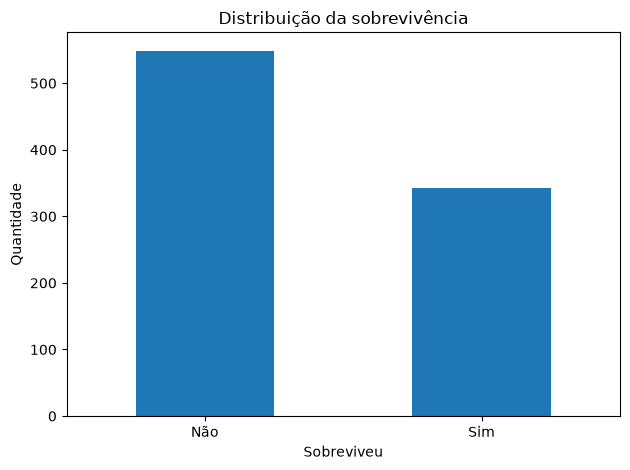

In [5]:
# Distribuição da variável-alvo
survival_counts = train_df["Survived"].value_counts().sort_index()
survival_counts.plot(kind="bar")
plt.title("Distribuição da sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")
plt.xticks([0, 1], ["Não", "Sim"], rotation=0)
plt.tight_layout()
plt.show()


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


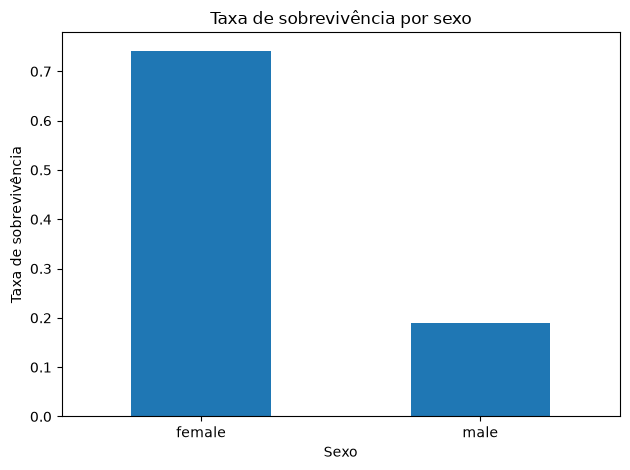

In [6]:
# Sobrevivência por sexo
survival_by_sex = pd.crosstab(
    train_df["Sex"], train_df["Survived"], normalize="index"
)
display(survival_by_sex)

survival_by_sex[1].plot(kind="bar")
plt.title("Taxa de sobrevivência por sexo")
plt.xlabel("Sexo")
plt.ylabel("Taxa de sobrevivência")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

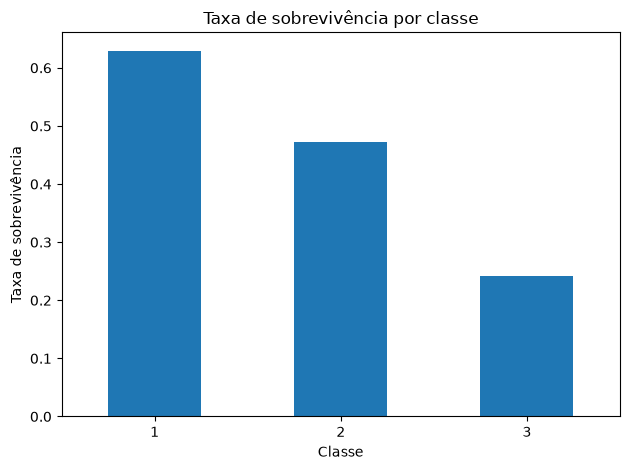

In [7]:
# Sobrevivência por classe
survival_by_class = train_df.groupby("Pclass")["Survived"].mean()
display(survival_by_class)

survival_by_class.plot(kind="bar")
plt.title("Taxa de sobrevivência por classe")
plt.xlabel("Classe")
plt.ylabel("Taxa de sobrevivência")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretação da EDA — Wagner

[Registrar aqui as interpretações dos gráficos sem confundir associação com causalidade.]


## 5. Engenharia de atributos — Vilela


In [8]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    result["FamilySize"] = result["SibSp"] + result["Parch"] + 1
    result["IsAlone"] = (result["FamilySize"] == 1).astype(int)

    result["Title"] = (
        result["Name"]
        .str.extract(r",\s*([^.]*)\.", expand=False)
        .str.strip()
        .replace(
            {
                "Mlle": "Miss",
                "Ms": "Miss",
                "Mme": "Mrs",
            }
        )
    )

    rare_titles = ~result["Title"].isin(["Mr", "Mrs", "Miss", "Master"])
    result.loc[rare_titles, "Title"] = "Rare"

    return result


train_model_df = add_features(train_df)
test_model_df = add_features(test_df)

display(train_model_df[["Name", "Title", "FamilySize", "IsAlone"]].head())


,Name,Title,FamilySize,IsAlone
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0
2,"Heikkinen, Miss. Laina",Miss,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0
4,"Allen, Mr. William Henry",Mr,1,1


## 6. Seleção das variáveis e separação treino/validação

A lista abaixo é inicial. Vitor e Vilela devem revisar juntos.


In [9]:
TARGET = "Survived"

numeric_features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
]

selected_features = numeric_features + categorical_features

X = train_model_df[selected_features]
y = train_model_df[TARGET]
X_test = test_model_df[selected_features]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(X_train.shape, X_valid.shape)


(712, 10) (179, 10)


## 7. Pipeline de pré-processamento — Vitor


In [10]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)


## 8. Modelos


In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=6,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

models = {
    "Regressão Logística": logistic_model,
    "Random Forest": random_forest_model,
}


## 9. Avaliação e comparação


In [12]:
def evaluate_model(name: str, model: Pipeline) -> dict:
    model.fit(X_train, y_train)
    predictions = model.predict(X_valid)

    cv_scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="accuracy",
    )

    print(f"\n{name}")
    print("Matriz de confusão:")
    print(confusion_matrix(y_valid, predictions))
    print("\nRelatório:")
    print(classification_report(y_valid, predictions))

    return {
        "Modelo": name,
        "Accuracy": accuracy_score(y_valid, predictions),
        "Precision": precision_score(y_valid, predictions, zero_division=0),
        "Recall": recall_score(y_valid, predictions, zero_division=0),
        "F1": f1_score(y_valid, predictions, zero_division=0),
        "CV média": cv_scores.mean(),
        "CV desvio": cv_scores.std(),
    }


results = []
for model_name, model in models.items():
    results.append(evaluate_model(model_name, model))

results_df = pd.DataFrame(results).sort_values("CV média", ascending=False)
display(results_df)



Regressão Logística
Matriz de confusão:
[[100  10]
 [ 16  53]]

Relatório:
              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179


Random Forest
Matriz de confusão:
[[100  10]
 [ 22  47]]

Relatório:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



,Modelo,Accuracy,Precision,Recall,F1,CV média,CV desvio
1,Random Forest,0.821229,0.824561,0.681159,0.746032,0.826025,0.017164
0,Regressão Logística,0.854749,0.841270,0.768116,0.803030,0.822673,0.025009


## 10. Escolha do modelo final — Vitor e Vilela

Registrar:

- modelo selecionado;
- justificativa;
- desempenho;
- estabilidade;
- interpretabilidade;
- possível overfitting.


In [13]:
best_model_name = results_df.iloc[0]["Modelo"]
best_model = models[best_model_name]

print("Modelo selecionado:", best_model_name)


Modelo selecionado: Random Forest


## 11. Treinamento final e geração da submissão — Vitor


In [14]:
best_model.fit(X, y)
test_predictions = best_model.predict(X_test).astype(int)

submission = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Survived": test_predictions,
    }
)

OUTPUT_DIR = Path("../outputs/submission")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSION_PATH = OUTPUT_DIR / "submission.csv"

submission.to_csv(SUBMISSION_PATH, index=False)

print("Arquivo gerado:", SUBMISSION_PATH)
display(submission.head())
print(submission.shape)


Arquivo gerado: ..\outputs\submission\submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


(418, 2)


## 12. Resultado da submissão — Wagner

- **Data:**
- **Modelo:**
- **Pontuação:**
- **Screenshot:**
- **Observações:**


## 13. Conclusão

[Wagner redige. Vitor e Vilela revisam tecnicamente.]

Incluir:

- principais padrões observados;
- comparação entre os modelos;
- modelo escolhido;
- limitações;
- possíveis evoluções.
